In [1]:
# !python3 -m pip install coppeliasim-zmqremoteapi-client
# !pip install torch scikit-learn

In [2]:
from coppeliasim_zmqremoteapi_client import RemoteAPIClient
import time
import numpy as np
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
import os
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

### Подключение к CoppeliaSim и дополнительные настройки

In [3]:
# Подключение к симулятору
client = RemoteAPIClient('127.0.0.1', 23000)
sim = client.require('sim')

# Описание суставов модели
joint_names = [
    'Revolute_Head_Spine_1', 'Revolute_Spine_1_2', 'Revolute_Spine_2_3',
    'Revolute_Spine_3_4', 'Revolute_Spine_4_LHip', 'Revolute_LH_LBL',
    'Revolute_Spine_4_RHip', 'Revolute_RH_RBL', 'Revolute_Spine_1_RForearm',
    'Revolute_RF_RFL', 'Revolute_Spine_1_LForearm', 'Revolute_LF_LFL',
]

# Идентификаторы суставов
joint_handles = {name: sim.getObjectHandle(name) for name in joint_names}
# Корневой объект модели
main_handle = sim.getObjectHandle('Spine_1')

# Амплитуда колебания каждого сустава в радианах относительно позиции покоя
joint_amp = {
    'Revolute_Head_Spine_1': 0.00,
    'Revolute_Spine_1_2': 0.00,
    'Revolute_Spine_2_3': 0.00,
    'Revolute_Spine_3_4': 0.00,
    'Revolute_Spine_4_LHip': -0.45,
    'Revolute_LH_LBL': 0.00,
    'Revolute_Spine_4_RHip': -0.45,
    'Revolute_RH_RBL': 0.00,
    'Revolute_Spine_1_LForearm': -0.45,
    'Revolute_LF_LFL': 0.00,
    'Revolute_Spine_1_RForearm':-0.45,
    'Revolute_RF_RFL': 0.00
}

# Фазовый сдвиг каждого сустава в радианах (pi - противофаза, 0 - фаза)
joint_phase = {
    'Revolute_Head_Spine_1': 0.00,
    'Revolute_Spine_1_2': 0.00,
    'Revolute_Spine_2_3': 0.00,
    'Revolute_Spine_3_4': 0.00,
    'Revolute_Spine_4_LHip': np.pi,
    'Revolute_LH_LBL': 0.00,
    'Revolute_Spine_4_RHip': 0.00,
    'Revolute_RH_RBL': 0.00,
    'Revolute_Spine_1_LForearm': 0.00,
    'Revolute_LF_LFL': 0.00,
    'Revolute_Spine_1_RForearm': np.pi,
    'Revolute_RF_RFL': 0.00
}

# Ограничения углов поворота в радианах
joint_limits = {
    'Revolute_Head_Spine_1': (0.0, 0.0),
    'Revolute_Spine_1_2': (0.0, 0.0),
    'Revolute_Spine_2_3': (0.0, 0.0),
    'Revolute_Spine_3_4': (0.0, 0.0),
    'Revolute_Spine_4_LHip': (-1.2, 1.2),
    'Revolute_LH_LBL': (0.0, 0.0),
    'Revolute_Spine_4_RHip': (-1.2, 1.2),
    'Revolute_RH_RBL': (0.0, 0.0),
    'Revolute_Spine_1_LForearm': (-1.2, 1.2),
    'Revolute_LF_LFL': (0.0, 0.0),
    'Revolute_Spine_1_RForearm': (-1.2, 1.2),
    'Revolute_RF_RFL': (0.0, 0.0)
}

gait_freq = 1.0 # гц
step_length = 0.01 # м
step_dt = 0.05 # с
seq_len = 10 # длина окна для LSTM

# Позиции покоя суставов (на момент запуска)
joint_rest = {
    name: float(sim.getJointPosition(joint_handles[name]))
    for name in joint_names
}

### Вспомогательные функции

In [4]:
# Синусоидальные целевые углы для момента t
def sinusoidal_targets(t: float, amp_override: dict = None) -> np.ndarray:
    amp = amp_override if amp_override is not None else joint_amp
    out = np.zeros(len(joint_names))
    for i, name in enumerate(joint_names):
        a = amp.get(name, joint_amp[name])
        out[i] = joint_rest[name] + a * np.sin(2 * np.pi * gait_freq * t + joint_phase[name])
    return out

# Входной вектор для нейросети (углы каждого сустава + sin/cos фазы цикла)
def get_state_with_phase(t: float) -> np.ndarray:
    positions = np.array([float(sim.getJointPosition(joint_handles[n])) for n in joint_names])
    phase = 2 * np.pi * gait_freq * t
    return np.concatenate([positions, [np.sin(phase), np.cos(phase)]])

# Защита от ошибки CBOR
def set_joint(name: str, value: float) -> None:
    sim.setJointTargetPosition(joint_handles[name], float(value))

# Применение вектора целевых углов ко всем суставам
def apply_targets(targets: np.ndarray) -> None:
    for i, name in enumerate(joint_names):
        low, high = joint_limits[name]
        set_joint(name, float(np.clip(targets[i], low, high)))

# Перемещение модели (только по оси X)
def set_object_position(offset: float, base_pos: list) -> None:
    sim.setObjectPosition(main_handle, -1, [float(base_pos[0] + offset), float(base_pos[1]), float(base_pos[2])])

### Ходьба без нейросети

In [5]:
# Скрипт ходьбы без применения нейросети
def walk(n_steps: int = 100):
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset = 0.0
    t = 0.0

    for _ in range(n_steps):
        apply_targets(sinusoidal_targets(t))
        time.sleep(step_dt)
        forward_offset += step_length
        set_object_position(forward_offset, pos)
        t += step_dt

### Сбор данных для обучения

In [6]:
# Вспомогательный сборщик одного эпизода с заданными параметрами
# Принимает history извне — для передачи буфера через границы эпизодов в LSTM
def _collect_episode(n_steps: int, amp_override: dict = None, freq_override: float = None, label: str = "", history: list = None) -> tuple:
    global gait_freq
    orig_freq = gait_freq
    if freq_override is not None:
        gait_freq = freq_override
    lstm_mode = history is not None
    if history is None:
        history = []
    buf = []
    sim.startSimulation()
    t = 0.0
    for step in range(n_steps):
        if lstm_mode:
            current = np.array([float(sim.getJointPosition(joint_handles[n])) for n in joint_names])
            history.append(current)
            if len(history) >= seq_len:
                buf.append({
                    'input':  np.stack(history[-seq_len:], axis=0),
                    'output': sinusoidal_targets(t + step_dt, amp_override=amp_override),
                })
        else:
            buf.append({
                'input':  get_state_with_phase(t),
                'output': sinusoidal_targets(t + step_dt, amp_override=amp_override),
            })
        apply_targets(sinusoidal_targets(t, amp_override=amp_override))
        time.sleep(step_dt)
        t += step_dt
    sim.stopSimulation()
    gait_freq = orig_freq
    return buf, history[-seq_len:] if history else []

def _collect_transition(n_steps: int, freq_from: float, freq_to: float, amp_from: dict = None, amp_to: dict = None, label: str = "", history: list = None) -> tuple:
    global gait_freq
    orig_freq = gait_freq
    if amp_from is None:
        amp_from = dict(joint_amp)
    if amp_to is None:
        amp_to = dict(joint_amp)
    lstm_mode = history is not None
    if history is None:
        history = []
    buf = []
    sim.startSimulation()
    t = 0.0
    for step in range(n_steps):
        alpha = step / max(n_steps - 1, 1)
        gait_freq = freq_from + alpha * (freq_to - freq_from)
        interp_amp = {
            name: amp_from[name] + alpha * (amp_to[name] - amp_from[name])
            for name in joint_names
        }
        if lstm_mode:
            current = np.array([float(sim.getJointPosition(joint_handles[n])) for n in joint_names])
            history.append(current)
            if len(history) >= seq_len:
                buf.append({
                    'input':  np.stack(history[-seq_len:], axis=0),
                    'output': sinusoidal_targets(t + step_dt, amp_override=interp_amp),
                })
        else:
            buf.append({
                'input':  get_state_with_phase(t),
                'output': sinusoidal_targets(t + step_dt, amp_override=interp_amp),
            })
        apply_targets(sinusoidal_targets(t, amp_override=interp_amp))
        time.sleep(step_dt)
        t += step_dt
    sim.stopSimulation()
    gait_freq = orig_freq
    return buf, history[-seq_len:] if history else []


# Используется для обучения WalkingNet и CPGNet
def walk_with_data_collection(n_steps: int = 4000, n_transition: int = 200):
    global data_buffer
    data_buffer = []
    limp_amp = dict(joint_amp)
    limp_amp['Revolute_Spine_4_LHip'] = -0.15
    limp_amp['Revolute_LH_LBL'] = 0.00
    # Эпизод 1: нормальная ходьба
    buf, _ = _collect_episode(n_steps, freq_override=1.0, label="Нормальная ходьба")
    data_buffer += buf
    # Переход 1-2: 1.0 -> 0.6 Гц
    buf, _ = _collect_transition(n_transition, freq_from=1.0, freq_to=0.6, label="1.0->0.6")
    data_buffer += buf
    # Эпизод 2: медленная ходьба
    buf, _ = _collect_episode(n_steps, freq_override=0.6, label="Медленная ходьба")
    data_buffer += buf
    # Переход 2-3: 0.6 -> 1.4 Гц
    buf, _ = _collect_transition(n_transition, freq_from=0.6, freq_to=1.4, label="0.6->1.4")
    data_buffer += buf
    # Эпизод 3: быстрая ходьба
    buf, _ = _collect_episode(n_steps, freq_override=1.4, label="Быстрая ходьба")
    data_buffer += buf
    # Переход 3-4: 1.4 -> 1.0 Гц + появление хромоты
    buf, _ = _collect_transition(n_transition, freq_from=1.4, freq_to=1.0, amp_from=dict(joint_amp), amp_to=limp_amp, label="1.4->хромота")
    data_buffer += buf
    # Эпизод 4: асимметричная/патологическая ходьба
    buf, _ = _collect_episode(n_steps, amp_override=limp_amp, freq_override=1.0, label="Асимметричная ходьба")
    data_buffer += buf
    # Переход 4-1: хромота -> нормальная ходьба
    buf, _ = _collect_transition(n_transition, freq_from=1.0, freq_to=1.0, amp_from=limp_amp, amp_to=dict(joint_amp), label="хромота->нормальная ходьба")
    data_buffer += buf
    # Сохранение
    with open('walking_data.pkl', 'wb') as f:
        pickle.dump(data_buffer, f)


# Используется для обучения LSTM
def walk_with_data_collection_lstm(n_steps: int = 4000, n_transition: int = 200):
    global data_buffer, gait_freq
    data_buffer = []
    limp_amp = dict(joint_amp)
    limp_amp['Revolute_Spine_4_LHip'] = -0.15
    # История передаётся сквозь все эпизоды и переходы
    history = []
    # Эпизод 1: нормальная ходьба
    buf, history = _collect_episode(n_steps, freq_override=1.0, label="Нормальная ходьба", history=history)
    data_buffer += buf
    # Переход 1-2
    buf, history = _collect_transition(n_transition, freq_from=1.0, freq_to=0.6, label="1.0->0.6", history=history)
    data_buffer += buf
    # Эпизод 2: медленная ходьба
    buf, history = _collect_episode(n_steps, freq_override=0.6, label="Медленная ходьба", history=history)
    data_buffer += buf
    # Переход 2-3
    buf, history = _collect_transition(n_transition, freq_from=0.6, freq_to=1.4, label="0.6->1.4", history=history)
    data_buffer += buf
    # Эпизод 3: быстрая ходьба
    buf, history = _collect_episode(n_steps, freq_override=1.4, label="Быстрая ходьба", history=history)
    data_buffer += buf
    # Переход 3-4
    buf, history = _collect_transition(n_transition, freq_from=1.4, freq_to=1.0, amp_from=dict(joint_amp), amp_to=limp_amp, label="1.4->хромота", history=history)
    data_buffer += buf
    # Эпизод 4: асимметричная ходьба
    buf, history = _collect_episode(n_steps, amp_override=limp_amp, freq_override=1.0, label="Асимметричная ходьба", history=history)
    data_buffer += buf
    # Переход 4-1: замыкание цикла
    buf, history = _collect_transition(n_transition, freq_from=1.0, freq_to=1.0, amp_from=limp_amp, amp_to=dict(joint_amp), label="хромота->нормальная ходьба", history=history)
    data_buffer += buf
    # Сохранение
    with open('walking_data_lstm.pkl', 'wb') as f:
        pickle.dump(data_buffer, f)

### Архитектуры нейронных сетей

In [7]:
# WalkingNet - полносвязная сеть
class WalkingNet(nn.Module):
    def __init__(self, input_size: int = 14, output_size: int = 12):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 256), nn.Tanh(),
            nn.Linear(256, 256), nn.Tanh(),
            nn.Linear(256, 128), nn.Tanh(),
            nn.Linear(128, output_size)
        )

    def forward(self, x):
        return self.net(x)


# WalkingLSTM - рекуррентная сеть
class WalkingLSTM(nn.Module):
    def __init__(self, input_size: int = 12, hidden_size: int = 128, num_layers: int = 2, output_size: int = 12):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.1)
        self.head = nn.Sequential(
            nn.Linear(hidden_size, 64), nn.Tanh(),
            nn.Linear(64, output_size)
        )

    def forward(self, x, hidden=None):
        out, hidden = self.lstm(x, hidden)
        return self.head(out[:, -1, :]), hidden


# CPGNet - сеть с центральным паттерн-генератором
class CPGNet(nn.Module):
    def __init__(self, state_size: int = 14, output_size: int = 12, correction_scale: float = 0.3):
        super().__init__()
        self.correction_scale = correction_scale
        self.corrector = nn.Sequential(
            nn.Linear(state_size, 128), nn.Tanh(),
            nn.Linear(128, 64), nn.Tanh(),
            nn.Linear(64, output_size),
            nn.Tanh()
        )

    def forward(self, state, cpg_target):
        return cpg_target + self.corrector(state) * self.correction_scale

### Обучение

In [8]:
# Загрузка walking_data.pkl
def _load_flat_data(pkl_file: str):
    data = pickle.load(open(pkl_file, 'rb'))
    inputs = torch.tensor(np.stack([d['input']  for d in data]), dtype=torch.float32)
    targets = torch.tensor(np.stack([d['output'] for d in data]), dtype=torch.float32)
    mean = inputs.mean(dim=0)
    std = inputs.std(dim=0).clamp(min=1e-6)
    return inputs, targets, mean, std


def _train_loop(model, loader, epochs, lr, dataset_len, label):
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    criterion = nn.MSELoss()
    history = []

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0.0
        for batch in loader:
            xb = batch[0]
            yb = batch[-1]
            optimizer.zero_grad()

            if isinstance(model, WalkingLSTM):
                pred, _ = model(xb)
            elif isinstance(model, CPGNet):
                cpg_b = batch[1]
                pred = model(xb, cpg_b)
            else:
                pred = model(xb)

            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            epoch_loss += loss.item() * len(xb)

        scheduler.step()
        avg = epoch_loss / dataset_len
        history.append(avg)
        if epoch % 200 == 0:
            print(f"[{label}] Epoch {epoch:4d}  loss={avg:.6f}"
                  f"  lr={scheduler.get_last_lr()[0]:.2e}")

    return history


def train_walkingnet(epochs: int = 2000, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl. Запустите walk_with_data_collection.")
        return
    inputs, targets, mean, std = _load_flat_data('walking_data.pkl')
    inputs_n = (inputs - mean) / std
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(inputs_n, targets),
        batch_size=batch_size, shuffle=True)
    model = WalkingNet()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'WalkingNet')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_model.pth')
    return model, history

def train_lstm(epochs: int = 2000, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists('walking_data_lstm.pkl'):
        print("Нет walking_data_lstm.pkl. Запустите walk_with_data_collection_lstm.")
        return
    data = pickle.load(open('walking_data_lstm.pkl', 'rb'))
    inputs = torch.tensor(np.stack([d['input']  for d in data]), dtype=torch.float32)
    targets = torch.tensor(np.stack([d['output'] for d in data]), dtype=torch.float32)
    flat = inputs.reshape(-1, inputs.shape[-1])
    mean = flat.mean(dim=0)
    std = flat.std(dim=0).clamp(min=1e-6)
    inputs_n = (inputs - mean) / std
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(inputs_n, targets),
        batch_size=batch_size, shuffle=True)
    model = WalkingLSTM()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'LSTM')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_lstm.pth')
    return model, history

def train_cpg(epochs: int = 1500, batch_size: int = 64, lr: float = 3e-4):
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl. Запустите walk_with_data_collection.")
        return
    inputs, targets, mean, std = _load_flat_data('walking_data.pkl')
    inputs_n = (inputs - mean) / std
    phases = torch.atan2(inputs[:, -2], inputs[:, -1])
    ts = (phases / (2 * np.pi * gait_freq)).numpy()
    cpg_basis = torch.tensor(np.stack([sinusoidal_targets(float(t)) for t in ts]), dtype=torch.float32)
    loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(inputs_n, cpg_basis, targets),
        batch_size=batch_size, shuffle=True)
    model = CPGNet()
    history = _train_loop(model, loader, epochs, lr, len(inputs), 'CPGNet')
    torch.save({'model': model.state_dict(), 'input_mean': mean, 'input_std': std, 'loss_history': history}, 'walking_cpg.pth')
    return model, history

# Обучение всех трех сетей
def train_all():
    print("═" * 60)
    print("1/3  WalkingNet")
    print("═" * 60)
    train_walkingnet()
    print("\n" + "═" * 60)
    print("2/3  LSTM")
    print("═" * 60)
    train_lstm()
    print("\n" + "═" * 60)
    print("3/3  CPGNet")
    print("═" * 60)
    train_cpg()

### Ходьба с применением нейросетей

In [9]:
# Ходьба с WalkingNet
def walk_with_wn(n_steps: int = 40):
    if not os.path.exists('walking_model.pth'):
        print("Нет walking_model.pth. Запустите train_walkingnet.")
        return
    ckpt = torch.load('walking_model.pth', weights_only=True)
    mean = ckpt['input_mean']
    std = ckpt['input_std']
    model = WalkingNet()
    model.load_state_dict(ckpt['model'])
    model.eval()
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    try:
        for step in range(n_steps):
            state = torch.tensor(get_state_with_phase(t), dtype=torch.float32).unsqueeze(0)
            with torch.no_grad():
                pred = model((state - mean) / std).numpy().flatten()
            apply_targets(pred)
            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

# Ходьба с LSTM
def walk_with_lstm(n_steps: int = 40):
    if not os.path.exists('walking_lstm.pth'):
        print("Нет walking_lstm.pth. Запустите train_lstm.")
        return
    ckpt = torch.load('walking_lstm.pth', weights_only=True)
    mean = ckpt['input_mean']
    std = ckpt['input_std']
    model = WalkingLSTM()
    model.load_state_dict(ckpt['model'])
    model.eval()
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    history, hidden = [], None
    try:
        for step in range(n_steps):
            current = np.array([float(sim.getJointPosition(joint_handles[n])) for n in joint_names])
            history.append(current)
            if len(history) < seq_len:
                apply_targets(sinusoidal_targets(t))
            else:
                seq = np.stack(history[-seq_len:], axis=0)
                inp = torch.tensor(seq, dtype=torch.float32).unsqueeze(0)
                inp = (inp - mean) / std
                with torch.no_grad():
                    pred, hidden = model(inp, hidden)
                apply_targets(pred.numpy().flatten())
            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

# Ходьба с CPGNet
def walk_with_cpg(n_steps: int = 40):
    if not os.path.exists('walking_cpg.pth'):
        print("Нет walking_cpg.pth. Запустите train_cpg.")
        return
    ckpt = torch.load('walking_cpg.pth', weights_only=True)
    mean = ckpt['input_mean']
    std = ckpt['input_std']
    model = CPGNet()
    model.load_state_dict(ckpt['model'])
    model.eval()
    sim.startSimulation()
    pos = sim.getObjectPosition(main_handle)
    forward_offset, t = 0.0, 0.0
    try:
        for step in range(n_steps):
            state = torch.tensor(get_state_with_phase(t), dtype=torch.float32).unsqueeze(0)
            cpg_tgt = torch.tensor(sinusoidal_targets(t), dtype=torch.float32).unsqueeze(0)
            state_n = (state - mean) / std
            with torch.no_grad():
                pred = model(state_n, cpg_tgt).numpy().flatten()
            apply_targets(pred)
            time.sleep(step_dt)
            forward_offset += step_length
            set_object_position(forward_offset, pos)
            t += step_dt
    except Exception as e:
        print(f"Ошибка: {e}")
    finally:
        sim.stopSimulation()
        print("Ходьба завершена.")

### Аналитика

1. Сравнение WalkingNet, LSTM и CPGNet по трём метрикам на одних данных:
- MAE - средняя абсолютная ошибка (рад), цель < 0.05
- MaxErr - максимальная ошибка по любому суставу (рад), цель < 0.15
- R2 - коэффициент детерминации, цель > 0.95

2. Выстраивание графика кривых loss всех моделей
3. Демонстрационный эксперимент: нормальная и патологическая ходьба

In [10]:
# Генерация двух наборов тракеторий (нормальная синусоидальная ходьба и ходьба с заблокированным левым тазобедренным суставом (нулевая амплитуда))
def experiment_normal_vs_pathological(n_steps: int = 100):
    # Нормальная ходьба
    t_arr  = np.arange(n_steps) * step_dt
    normal = np.stack([sinusoidal_targets(t) for t in t_arr])
    # Заблокированный левый тазобедренный сустав
    limp_amp = dict(joint_amp)
    limp_amp['Revolute_Spine_4_LHip'] = 0.0 # амплитуда
    pathological = np.stack([sinusoidal_targets(t, amp_override=limp_amp) for t in t_arr])
    diff = pathological - normal
    # Индексы подвижных суставов
    active_idx = [i for i, n in enumerate(joint_names) if joint_amp[n] != 0.0]
    active_names = [joint_names[i] for i in active_idx]
    # Метрики
    print(f"\n{'Сустав':42s}  {'MAE (рад)':>10}  {'Max |Δ| (рад)':>14}")
    print("─" * 70)
    for i, name in zip(active_idx, active_names):
        mae = np.abs(diff[:, i]).mean()
        maxerr = np.abs(diff[:, i]).max()
        flag = " ← заблокирован" if 'LHip' in name else ""
        print(f"{name:42s}  {mae:10.4f}  {maxerr:14.4f}{flag}")
    # Суммарная MAE по всем суставам
    global_mae = np.abs(diff).mean()
    print(f"\nСуммарная MAE (все суставы): {global_mae:.4f} рад")
    # Графики
    n_active = len(active_idx)
    fig, axes = plt.subplots(n_active, 1, figsize=(12, 3 * n_active), sharex=True)
    if n_active == 1:
        axes = [axes]
    for ax, i, name in zip(axes, active_idx, active_names):
        ax.plot(t_arr, normal[:, i], label='Нормальная', color='steelblue', lw=1.5)
        ax.plot(t_arr, pathological[:, i], label='Патологическая/Асимметричная', color='tomato', lw=1.5, ls='--')
        ax.fill_between(t_arr, normal[:, i], pathological[:, i], alpha=0.15, color='tomato')
        short = name.replace('Revolute_', '').replace('Spine_', 'S_')
        ax.set_ylabel(f'{short}\n(рад)', fontsize=8)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.3)
    axes[-1].set_xlabel('Время (с)')
    fig.suptitle('Нормальная ходьба и заблокированный левый тазобедренный сустав', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('experiment_normal_vs_pathological.png', dpi=150, bbox_inches='tight')

# Графики сравнения для предсказанных и реальных углов суставов
def _plot_pred_vs_real(model_name: str, targets: np.ndarray, pred: np.ndarray, t_arr: np.ndarray, out_file: str):
    n_joints = len(joint_names)
    ncols = 3
    nrows = int(np.ceil(n_joints / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 3 * nrows))
    axes = axes.flatten()
    for i, name in enumerate(joint_names):
        ax = axes[i]
        ax.plot(t_arr, targets[:, i], label='Реальные', color='steelblue', lw=1.5)
        ax.plot(t_arr, pred[:, i], label='Предсказанные', color='tomato', lw=1.2, ls='--')
        mae = np.abs(pred[:, i] - targets[:, i]).mean()
        short = name.replace('Revolute_', '').replace('Spine_', 'S_')
        ax.set_title(f'{short}\nMAE={mae:.4f} рад', fontsize=9)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
    for j in range(n_joints, len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f'{model_name}: предсказанные и реальные углы суставов', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(out_file, dpi=150, bbox_inches='tight')

# Вычисление R2 с анализом: если дисперсия целевых значений близка к нулю, то R2 = nan (почти константный сигнал => R2 неинформативна)
def _compute_r2_safe(y_true: np.ndarray, y_pred: np.ndarray) -> float:
    var_y = np.var(y_true)
    if var_y < 1e-8:
        return float('nan')
    return float(r2_score(y_true, y_pred))

# Форматирует R2 с пометкой, если значение NaN или < 0
def _r2_str(val) -> str:
    if val != val:
        return "   n/a  (дисп.≈0)"
    if val < 0:
        return f"{val:7.4f} ⚠ (хуже mean)"
    if val > 0.95:
        return f"{val:7.4f} ✓"
    return f"{val:7.4f}"

# Вычисление baseline метрик
def _baseline_metrics(targets: np.ndarray) -> dict:
    n = len(targets)
    t_arr = np.arange(n) * step_dt
    mean_pred = np.tile(targets.mean(axis=0), (n, 1))
    mae_mean  = float(np.abs(mean_pred - targets).mean())
    sin_pred = np.stack([sinusoidal_targets(t) for t in t_arr])
    mae_sin  = float(np.abs(sin_pred - targets).mean())
    phases   = 2 * np.pi * gait_freq * t_arr
    X_phase  = np.column_stack([np.sin(phases), np.cos(phases)])
    lr_model = LinearRegression().fit(X_phase, targets)
    lr_pred  = lr_model.predict(X_phase)
    mae_lr   = float(np.abs(lr_pred - targets).mean())
    return {
        'MeanPredictor': {'MAE': mae_mean, 'pred': mean_pred},
        'Sinusoidal': {'MAE': mae_sin, 'pred': sin_pred},
        'LinearReg': {'MAE': mae_lr, 'pred': lr_pred},
    }

# Вычисление R2 отдельно для каждого сустава
def _compute_r2_per_joint(y_true: np.ndarray, y_pred: np.ndarray, var_threshold: float = 1e-6) -> np.ndarray:
    n_joints = y_true.shape[1]
    r2_vals  = np.full(n_joints, np.nan)
    for j in range(n_joints):
        var_j = np.var(y_true[:, j])
        if var_j >= var_threshold:
            r2_vals[j] = r2_score(y_true[:, j], y_pred[:, j])
    return r2_vals

# Агрегированный R2 только по активным суставам
def _compute_r2_active(y_true: np.ndarray, y_pred: np.ndarray, var_threshold: float = 1e-6) -> float:
    r2_per = _compute_r2_per_joint(y_true, y_pred, var_threshold)
    active = r2_per[~np.isnan(r2_per)]
    return float(np.mean(active)) if len(active) > 0 else float('nan')

# Форматирование R2
def _r2_str_v2(val: float) -> str:
    if np.isnan(val):
        return "n/a  (все суставы неподвижны)"
    if val < 0:
        return f"{val:8.4f} Хуже mean (< 0)"
    if val >= 0.95:
        return f"{val:8.4f} Отлично (>= 0.95)"
    if val >= 0.80:
        return f"{val:8.4f} Хорошо (>= 0.8)"
    return f"{val:8.4f}"

# Вывод таблицы R2 по каждому суставу
def _print_per_joint_r2(model_name: str, y_true: np.ndarray, y_pred: np.ndarray, joint_names: list, var_threshold: float = 1e-6):
    r2_vals = _compute_r2_per_joint(y_true, y_pred, var_threshold)
    print(f"\n  [{model_name}] R2 по суставам (var_threshold={var_threshold:.0e}):")
    print(f"  {'Сустав':42s}  {'Дисп. цели':>12}  {'R2':>20}")
    print("  " + "─" * 78)
    for j, jname in enumerate(joint_names):
        var_j = np.var(y_true[:, j])
        short = jname.replace('Revolute_', '').replace('Spine_', 'S_')
        if np.isnan(r2_vals[j]):
            r2_s = "n/a (неподвижен)"
        else:
            r2_s = _r2_str_v2(r2_vals[j])
        print(f"  {short:42s}  {var_j:12.2e}  {r2_s}")
    active_r2 = r2_vals[~np.isnan(r2_vals)]
    if len(active_r2) > 0:
        print(f"\n  Средний R2 по активным суставам: {np.mean(active_r2):.4f}"
              f"  (n_active={len(active_r2)}/{len(joint_names)})")


# Сравнение моделей
def compare_models():
    if not os.path.exists('walking_data.pkl'):
        print("Нет walking_data.pkl."); return
    data    = pickle.load(open('walking_data.pkl', 'rb'))
    inputs  = np.stack([d['input']  for d in data])
    targets = np.stack([d['output'] for d in data])
    inp_t   = torch.tensor(inputs, dtype=torch.float32)
    n       = len(targets)
    t_arr   = np.arange(n) * step_dt

    # Диагностика дисперсии
    var_targets = np.var(targets, axis=0)
    print("\n─── Диагностика дисперсии целевых углов ───────────────────────")
    print(f"  {'Сустав':42s}  {'Дисперсия':>12}  {'Статус':>12}")
    print("  " + "─" * 70)
    for j, jname in enumerate(joint_names):
        short  = jname.replace('Revolute_', '').replace('Spine_', 'S_')
        status = "Активен" if var_targets[j] >= 1e-6 else "Неподвижен"
        print(f"  {short:42s}  {var_targets[j]:12.2e}  {status}")
    n_active = np.sum(var_targets >= 1e-6)
    print(f"\n  Активных суставов: {n_active}/{len(joint_names)}\n")

    # Baseline
    baselines = _baseline_metrics(targets)
    print("─── Baseline ────────────────────────────────────────────────────")
    print(f"{'Метод':20s}  {'MAE':>10}  {'R2 (активные)':>20}")
    print("─" * 55)
    for bname, bm in baselines.items():
        r2_act = _compute_r2_active(targets, bm['pred'])
        print(f"{bname:20s}  {bm['MAE']:10.4f}  {_r2_str_v2(r2_act)}")
    print()
    results     = {}
    loss_curves = {}
    preds_dict  = {}

    # WalkingNet
    if os.path.exists('walking_model.pth'):
        ckpt = torch.load('walking_model.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = WalkingNet(); net.load_state_dict(ckpt['model']); net.eval()
        with torch.no_grad():
            pred = net((inp_t - mean) / std).numpy()
        preds_dict['WalkingNet'] = (pred, targets, t_arr)
        r2_active = _compute_r2_active(targets, pred)
        results['WalkingNet'] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': r2_active,
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['WalkingNet'] = ckpt['loss_history']

    # CPGNet
    if os.path.exists('walking_cpg.pth'):
        ckpt = torch.load('walking_cpg.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = CPGNet(); net.load_state_dict(ckpt['model']); net.eval()
        phases = np.arctan2(inputs[:, -2], inputs[:, -1])
        ts = phases / (2 * np.pi * gait_freq)
        cpg_basis = torch.tensor(np.stack([sinusoidal_targets(float(t)) for t in ts]), dtype=torch.float32)
        with torch.no_grad():
            pred = net((inp_t - mean) / std, cpg_basis).numpy()
        preds_dict['CPGNet'] = (pred, targets, t_arr)
        r2_active = _compute_r2_active(targets, pred)
        results['CPGNet'] = {
            'MAE': float(np.abs(pred - targets).mean()),
            'MaxErr': float(np.abs(pred - targets).max()),
            'R2': r2_active,
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['CPGNet'] = ckpt['loss_history']

    # LSTM
    if os.path.exists('walking_lstm.pth') and os.path.exists('walking_data_lstm.pkl'):
        ckpt = torch.load('walking_lstm.pth', weights_only=True)
        mean, std = ckpt['input_mean'], ckpt['input_std']
        net = WalkingLSTM(); net.load_state_dict(ckpt['model']); net.eval()
        lstm_data = pickle.load(open('walking_data_lstm.pkl', 'rb'))
        lstm_inputs = torch.tensor(np.stack([d['input'] for d in lstm_data]), dtype=torch.float32)
        lstm_tgts = np.stack([d['output'] for d in lstm_data])
        lstm_t_arr = np.arange(len(lstm_tgts)) * step_dt
        lstm_n = (lstm_inputs - mean) / std
        with torch.no_grad():
            pred, _ = net(lstm_n)
        pred = pred.numpy()
        preds_dict['LSTM'] = (pred, lstm_tgts, lstm_t_arr)
        r2_active = _compute_r2_active(lstm_tgts, pred)
        results['LSTM'] = {
            'MAE': float(np.abs(pred - lstm_tgts).mean()),
            'MaxErr': float(np.abs(pred - lstm_tgts).max()),
            'R2': r2_active,
            'pred': pred,
        }
        if 'loss_history' in ckpt:
            loss_curves['LSTM'] = ckpt['loss_history']

    if not results:
        print("Нет обученных моделей для сравнения"); return

    # Сводная таблица
    print(f"\n{'Модель':15s}  {'MAE':>10}  {'MaxErr':>10}  "
          f"{'R2 (активные суставы)':>25}")
    print("─" * 68)
    for name, m in results.items():
        mae_ok = "Ок" if m['MAE']    < 0.05 else "Не ок"
        max_ok = "Ок" if m['MaxErr'] < 0.15 else "Не ок"
        print(f"{name:15s}  {m['MAE']:9.4f}{mae_ok}  "
              f"{m['MaxErr']:9.4f}{max_ok}  {_r2_str_v2(m['R2'])}")

    best = min(results, key=lambda k: results[k]['MAE'])
    print(f"\n  Лучшая по MAE: {best}")

    # R2 по суставам для каждой модели
    if 'WalkingNet' in results:
        _print_per_joint_r2('WalkingNet', targets, results['WalkingNet']['pred'], joint_names)
    if 'CPGNet' in results:
        _print_per_joint_r2('CPGNet', targets, results['CPGNet']['pred'], joint_names)
    if 'LSTM' in results:
        _, lstm_tgts, _ = preds_dict['LSTM']
        _print_per_joint_r2('LSTM', lstm_tgts, results['LSTM']['pred'], joint_names)

    # Кривые обучения
    if loss_curves:
        fig, axes = plt.subplots(1, 2, figsize=(13, 4))
        fig.suptitle("Кривые потерь (loss)")
        for name, hist in loss_curves.items():
            axes[0].plot(hist, label=name)
        axes[0].set(title='Loss (все эпохи)', xlabel='Эпоха', ylabel='MSE')
        axes[0].set_yscale('log'); axes[0].legend()
        for name, hist in loss_curves.items():
            tail = hist[int(len(hist) * 0.8):]
            start = len(hist) - len(tail)
            axes[1].plot(range(start, len(hist)), tail, label=name)
        axes[1].set(title='Loss (последние 20%)', xlabel='Эпоха', ylabel='MSE')
        axes[1].legend()
        plt.tight_layout()
        plt.savefig('loss_comparison.png', dpi=120, bbox_inches='tight')

    # Графики pred vs real
    for mname, (pred, tgt, ta) in preds_dict.items():
        _plot_pred_vs_real(mname, tgt, pred, ta, f'pred_vs_real_{mname.lower()}.png')

    return results

### Меню


════════════════════════════════════════════════════════════
  Доступные команды
════════════════════════════════════════════════════════════
  Сбор данных   : collect, collect_lstm
  Обучение      : train_wn, train_lstm, train_cpg, train_all
  Ходьба        : walk, walk_wn, walk_lstm, walk_cpg
  Анализ        : compare, experiment
  Выход         : stop
════════════════════════════════════════════════════════════
════════════════════════════════════════════════════════════
1/3  WalkingNet
════════════════════════════════════════════════════════════
[WalkingNet] Epoch    0  loss=0.018147  lr=3.00e-04
[WalkingNet] Epoch  200  loss=0.000077  lr=2.93e-04
[WalkingNet] Epoch  400  loss=0.000065  lr=2.71e-04
[WalkingNet] Epoch  600  loss=0.000063  lr=2.38e-04
[WalkingNet] Epoch  800  loss=0.000062  lr=1.96e-04
[WalkingNet] Epoch 1000  loss=0.000062  lr=1.50e-04
[WalkingNet] Epoch 1200  loss=0.000060  lr=1.03e-04
[WalkingNet] Epoch 1400  loss=0.000060  lr=6.16e-05
[WalkingNet] Epoch 1600  lo

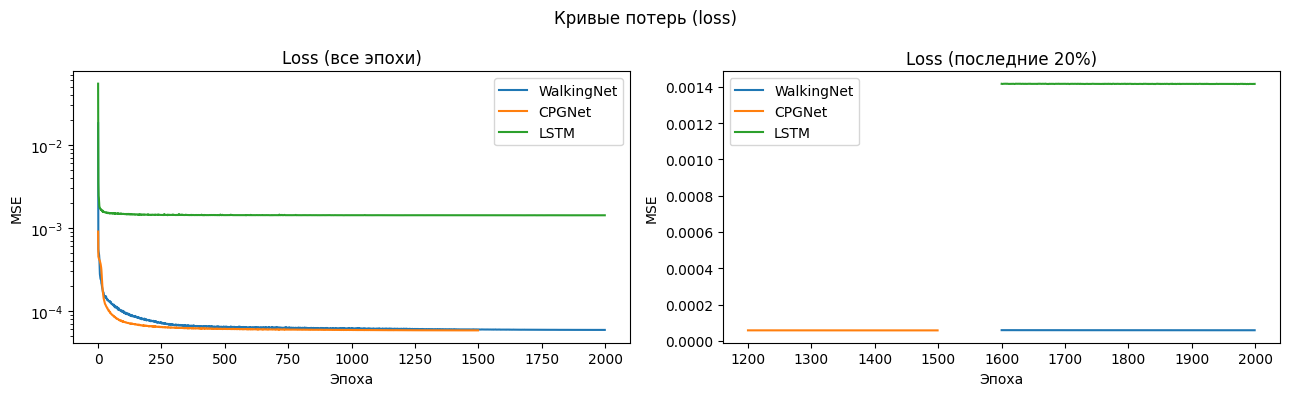

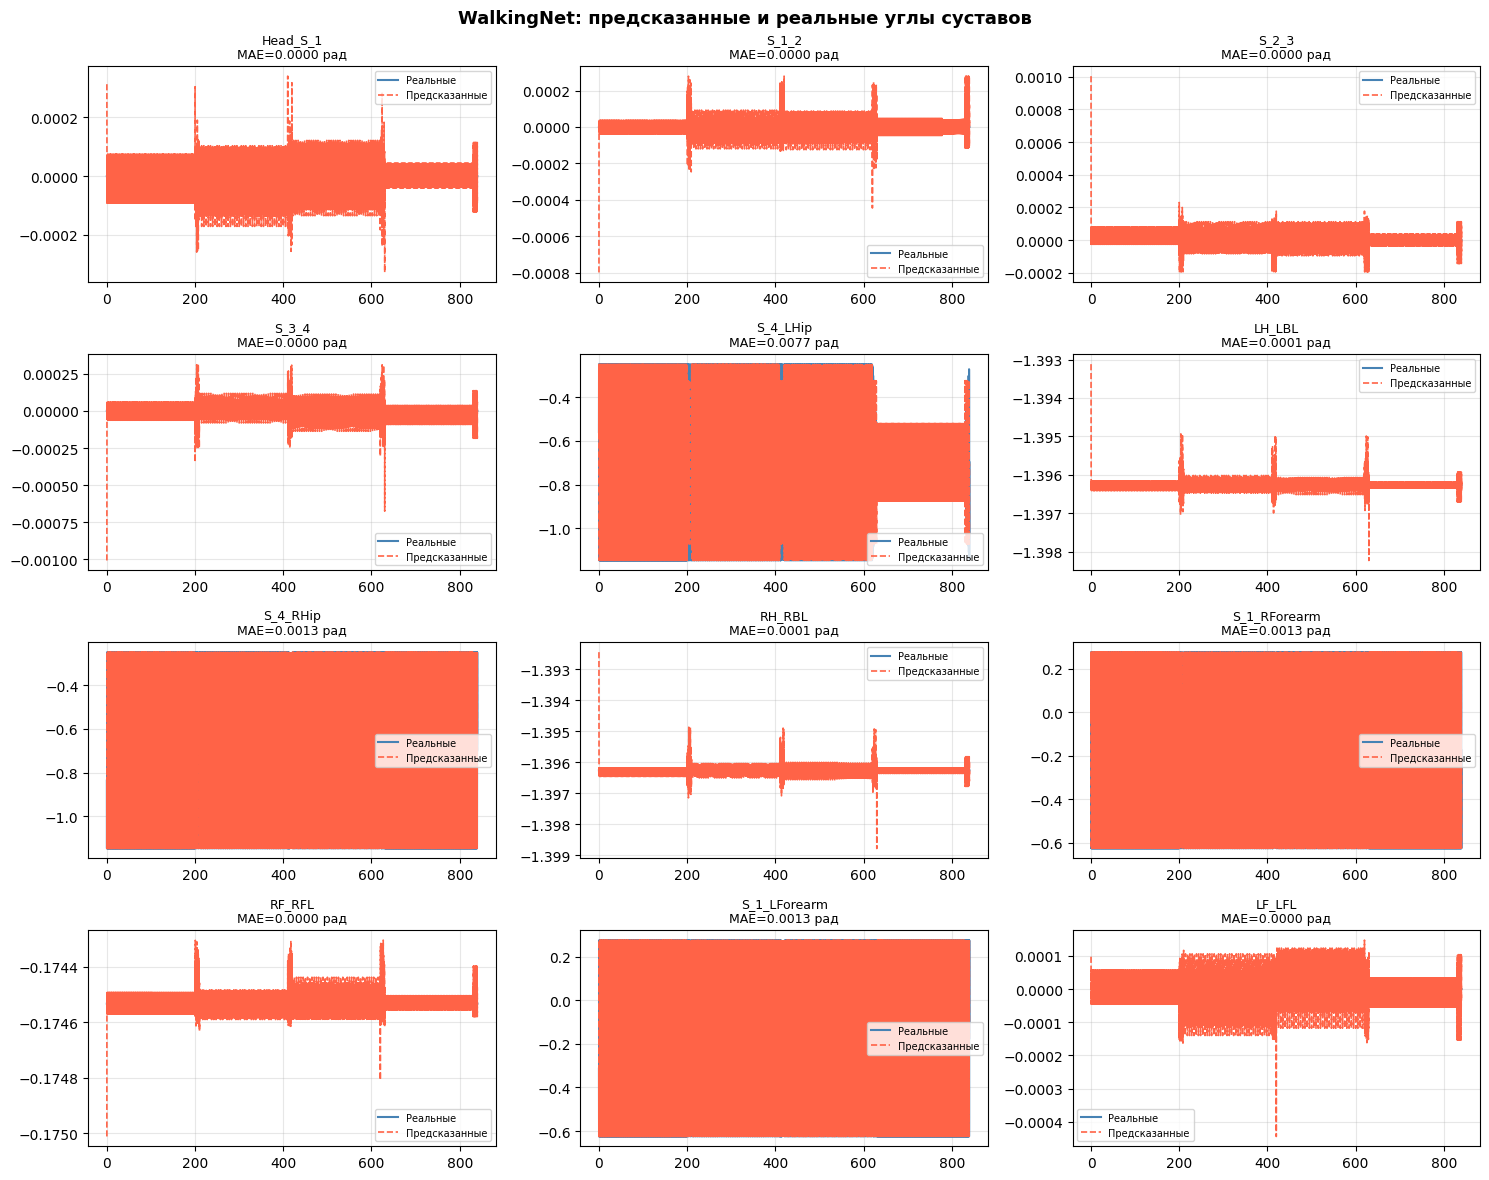

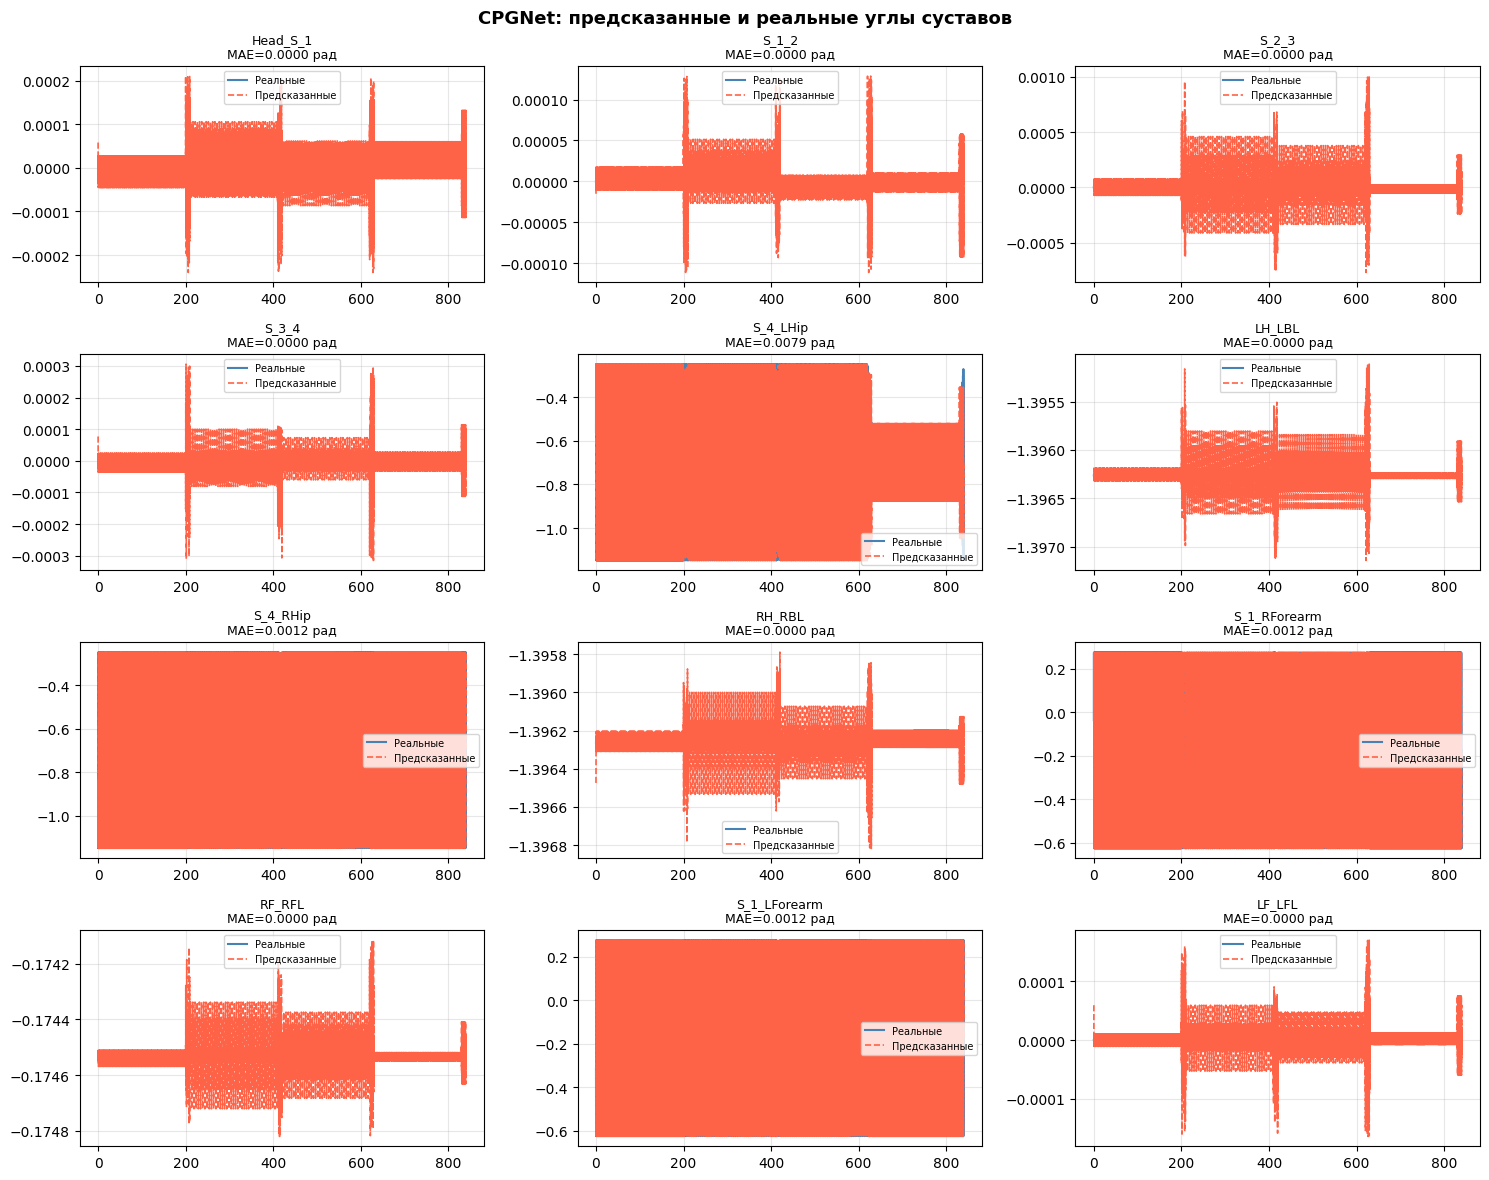

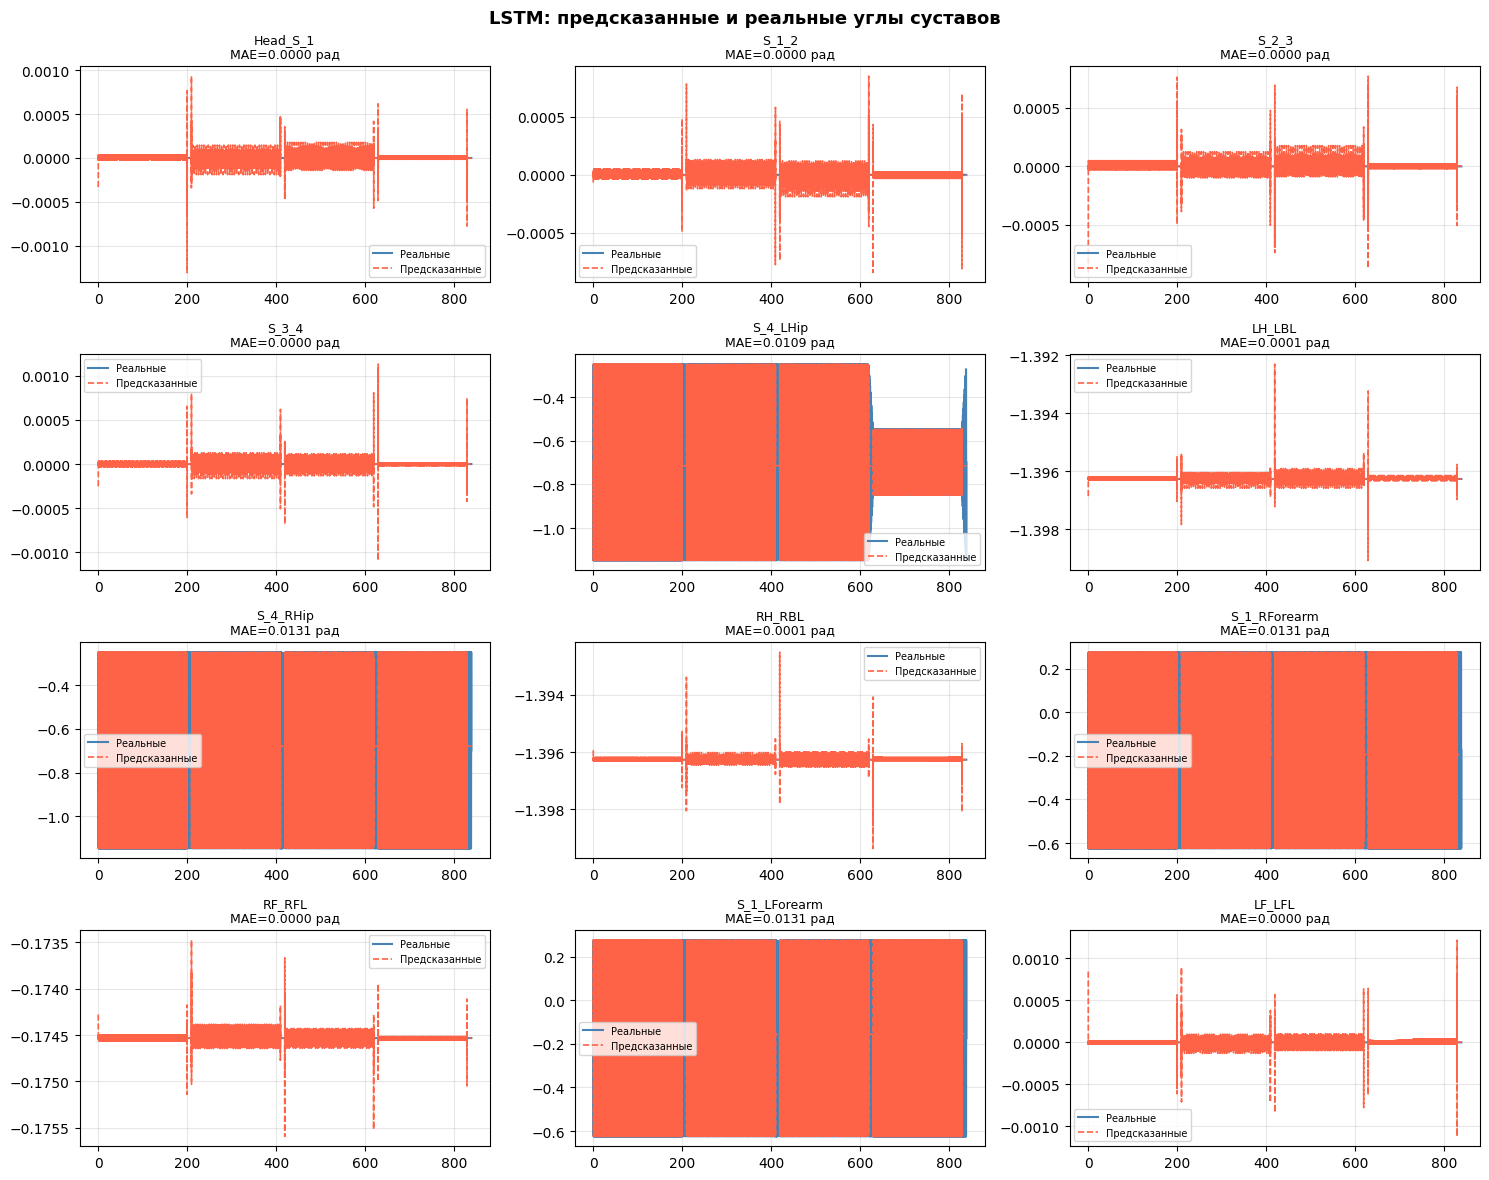

In [11]:
def main():
    commands = {
        # Сбор данных
        'collect':       walk_with_data_collection,
        'collect_lstm':  walk_with_data_collection_lstm,
        # Обучение
        'train_wn':      train_walkingnet,
        'train_lstm':    train_lstm,
        'train_cpg':     train_cpg,
        'train_all':     train_all,
        # Ходьба
        'walk':          walk,
        'walk_wn':       walk_with_wn,
        'walk_lstm':     walk_with_lstm,
        'walk_cpg':      walk_with_cpg,
        # Анализ
        'compare':       compare_models,
        # Эксперимент: нормальная vs патологическая (замечание 4)
        'experiment':    experiment_normal_vs_pathological,
    }
 
    print("\n" + "═" * 60)
    print("  Доступные команды")
    print("═" * 60)
    groups = [
        ("Сбор данных", ['collect', 'collect_lstm']),
        ("Обучение",    ['train_wn', 'train_lstm', 'train_cpg', 'train_all']),
        ("Ходьба",      ['walk', 'walk_wn', 'walk_lstm', 'walk_cpg']),
        ("Анализ",      ['compare', 'experiment']),
        ("Выход",       ['stop']),
    ]
    for group, cmds in groups:
        print(f"  {group:14s}: {', '.join(cmds)}")
    print("═" * 60)
 
    while True:
        cmd = input("\nКоманда: ").strip().lower()
        if cmd == 'stop':
            break
        elif cmd in commands:
            commands[cmd]()
        else:
            print(f"  Неизвестная команда: '{cmd}'")
 
 
if __name__ == '__main__':
    try:
        main()
    except KeyboardInterrupt:
        print("\nПрервано пользователем")
    finally:
        sim.stopSimulation()
        print("Симуляция остановлена")